# Bayesian Inference — Sequential Belief Updating in a Job Search

How should rejection or success at the application stage update your belief that you are a strong fit for a role?

This notebook models a job search as a Bayesian inference problem. Three role types (A, B, C) have different prior probabilities of fit. As application outcomes arrive, beliefs are updated sequentially.

**The core question:** given a rejection, how much should you revise your belief that you are a strong candidate?

The answer depends critically on the **likelihood of rejection even for strong candidates** — which in competitive job markets is surprisingly high.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Parameters

**Priors** — baseline belief of being a strong fit before any applications:

| Role | Prior P(fit) | Rationale |
|------|-------------|----------|
| A    | 0.20        | High skill match, niche role |
| B    | 0.10        | Moderate match, more competition |
| C    | 0.08        | Differentiated but highly competitive |

**Likelihoods** — how informative is a rejection?
- P(rejection | strong fit) = 0.55 — even strong candidates are often filtered out due to volume and competition
- P(rejection | weak fit)   = 0.92 — weak candidates are almost always rejected

In [2]:
# Priors: P(strong fit) for each role type
priors = {'A': 0.20, 'B': 0.10, 'C': 0.08}

# Likelihoods
p_reject_given_fit    = 0.55  # P(rejection | strong fit)
p_reject_given_no_fit = 0.92  # P(rejection | weak fit)

p_interview_given_fit    = 1 - p_reject_given_fit     # P(interview | strong fit)
p_interview_given_no_fit = 1 - p_reject_given_no_fit  # P(interview | weak fit)

def bayes_update(prior, outcome):
    """
    Update belief of being a strong fit given an outcome.
    outcome: 'rejection' or 'interview'
    """
    if outcome == 'rejection':
        p_obs_given_fit    = p_reject_given_fit
        p_obs_given_no_fit = p_reject_given_no_fit
    else:  # interview
        p_obs_given_fit    = p_interview_given_fit
        p_obs_given_no_fit = p_interview_given_no_fit

    # Total probability of this outcome
    p_obs = p_obs_given_fit * prior + p_obs_given_no_fit * (1 - prior)

    # Posterior via Bayes
    return (p_obs_given_fit * prior) / p_obs

def apply_sequence(prior, outcomes):
    """Apply a sequence of outcomes and return the full belief trajectory."""
    trajectory = [prior]
    belief = prior
    for outcome in outcomes:
        belief = bayes_update(belief, outcome)
        trajectory.append(belief)
    return trajectory

## Current State — Role A (Two Rejections with Feedback)

In [3]:
# Role A: two rejections observed so far
outcomes_A = ['rejection', 'rejection']
trajectory_A = apply_sequence(priors['A'], outcomes_A)

print("Role A — Belief trajectory:")
labels = ['Prior'] + [f'After rejection {i+1}' for i in range(len(outcomes_A))]
for label, belief in zip(labels, trajectory_A):
    print(f"  {label:25s}: {belief:.4f} ({belief:.1%})")

print(f"\nPrior belief of strong fit : {priors['A']:.1%}")
print(f"Posterior after 2 rejections: {trajectory_A[-1]:.1%}")
print(f"Belief reduction            : {(priors['A'] - trajectory_A[-1]):.1%} absolute")

Role A — Belief trajectory:
  Prior                    : 0.2000 (20.0%)
  After rejection 1        : 0.1300 (13.0%)
  After rejection 2        : 0.0820 (8.2%)

Prior belief of strong fit : 20.0%
Posterior after 2 rejections: 8.2%
Belief reduction            : 11.8% absolute


## What if an Interview Comes In?

How quickly does a single positive signal (interview) reverse the downward trend?

In [4]:
# Scenario: 2 rejections followed by 1 interview
trajectory_A_recovery = apply_sequence(priors['A'], ['rejection', 'rejection', 'interview'])

print("Role A — Recovery after interview:")
labels = ['Prior', 'After rejection 1', 'After rejection 2', 'After interview']
for label, belief in zip(labels, trajectory_A_recovery):
    print(f"  {label:25s}: {belief:.4f} ({belief:.1%})")

Role A — Recovery after interview:
  Prior                    : 0.2000 (20.0%)
  After rejection 1        : 0.1300 (13.0%)
  After rejection 2        : 0.0820 (8.2%)
  After interview          : 0.3345 (33.4%)


## Visualisation — Belief Trajectories Across Role Types

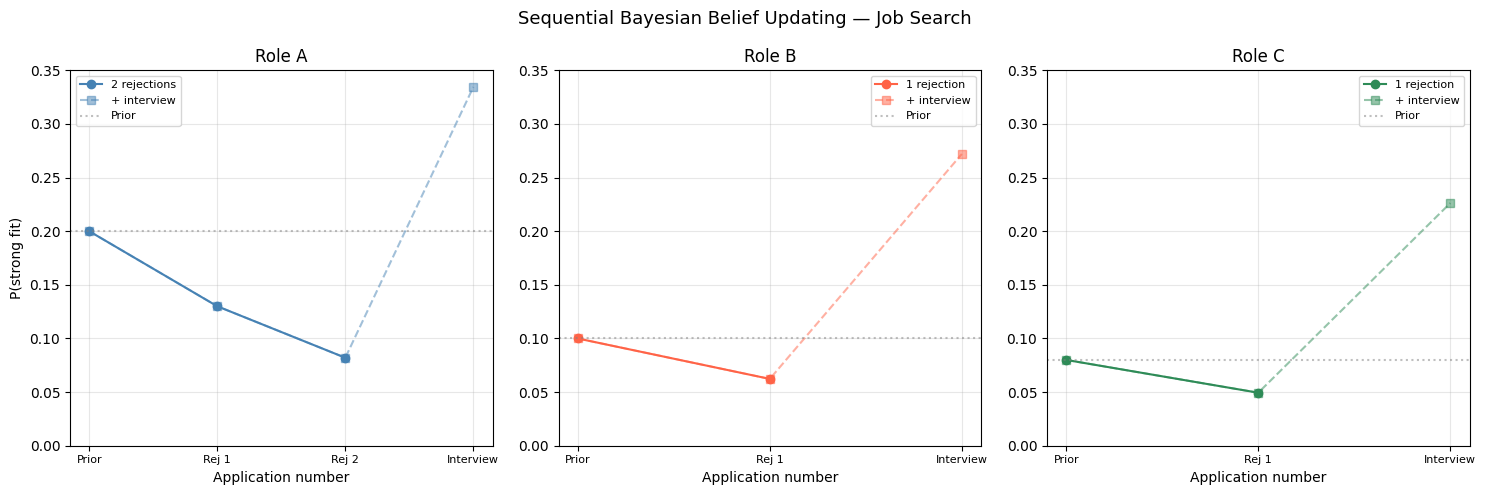

In [5]:
# Simulate trajectories for all three role types
# Role A: 2 rejections (observed), then hypothetical interview
# Role B: no data yet — show what 1 or 2 rejections would do
# Role C: no data yet — same

scenarios = {
    'A (2 rejections)':          apply_sequence(priors['A'], ['rejection', 'rejection']),
    'A (2 rej + interview)':     apply_sequence(priors['A'], ['rejection', 'rejection', 'interview']),
    'B (no data yet)':           apply_sequence(priors['B'], []),
    'B (1 rejection)':           apply_sequence(priors['B'], ['rejection']),
    'C (no data yet)':           apply_sequence(priors['C'], []),
    'C (1 rejection)':           apply_sequence(priors['C'], ['rejection']),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {'A': 'steelblue', 'B': 'tomato', 'C': 'seagreen'}

# Role A
ax = axes[0]
t1 = apply_sequence(priors['A'], ['rejection', 'rejection'])
t2 = apply_sequence(priors['A'], ['rejection', 'rejection', 'interview'])
ax.plot(t1, 'o-', color='steelblue', label='2 rejections')
ax.plot(t2, 's--', color='steelblue', alpha=0.5, label='+ interview')
ax.axhline(priors['A'], color='gray', linestyle=':', alpha=0.5, label='Prior')
ax.set_title('Role A')
ax.set_xlabel('Application number')
ax.set_ylabel('P(strong fit)')
ax.set_xticks(range(len(t2)))
ax.set_xticklabels(['Prior', 'Rej 1', 'Rej 2', 'Interview'], fontsize=8)
ax.legend(fontsize=8)
ax.set_ylim(0, 0.35)

# Role B
ax = axes[1]
t1 = apply_sequence(priors['B'], ['rejection'])
t2 = apply_sequence(priors['B'], ['rejection', 'interview'])
ax.plot(t1, 'o-', color='tomato', label='1 rejection')
ax.plot(t2, 's--', color='tomato', alpha=0.5, label='+ interview')
ax.axhline(priors['B'], color='gray', linestyle=':', alpha=0.5, label='Prior')
ax.set_title('Role B')
ax.set_xlabel('Application number')
ax.set_xticks(range(len(t2)))
ax.set_xticklabels(['Prior', 'Rej 1', 'Interview'], fontsize=8)
ax.legend(fontsize=8)
ax.set_ylim(0, 0.35)

# Role C
ax = axes[2]
t1 = apply_sequence(priors['C'], ['rejection'])
t2 = apply_sequence(priors['C'], ['rejection', 'interview'])
ax.plot(t1, 'o-', color='seagreen', label='1 rejection')
ax.plot(t2, 's--', color='seagreen', alpha=0.5, label='+ interview')
ax.axhline(priors['C'], color='gray', linestyle=':', alpha=0.5, label='Prior')
ax.set_title('Role C')
ax.set_xlabel('Application number')
ax.set_xticks(range(len(t2)))
ax.set_xticklabels(['Prior', 'Rej 1', 'Interview'], fontsize=8)
ax.legend(fontsize=8)
ax.set_ylim(0, 0.35)

plt.suptitle('Sequential Bayesian Belief Updating — Job Search', fontsize=13)
plt.tight_layout()
plt.savefig('bayesian_job_search.png', dpi=150)
plt.show()

## Portfolio View — Probability of At Least One Interview

If you apply to N roles of a given type, what is the probability of getting at least one interview?

$$P(\text{at least one interview}) = 1 - P(\text{all rejections}) = 1 - (1 - p_{interview})^N$$

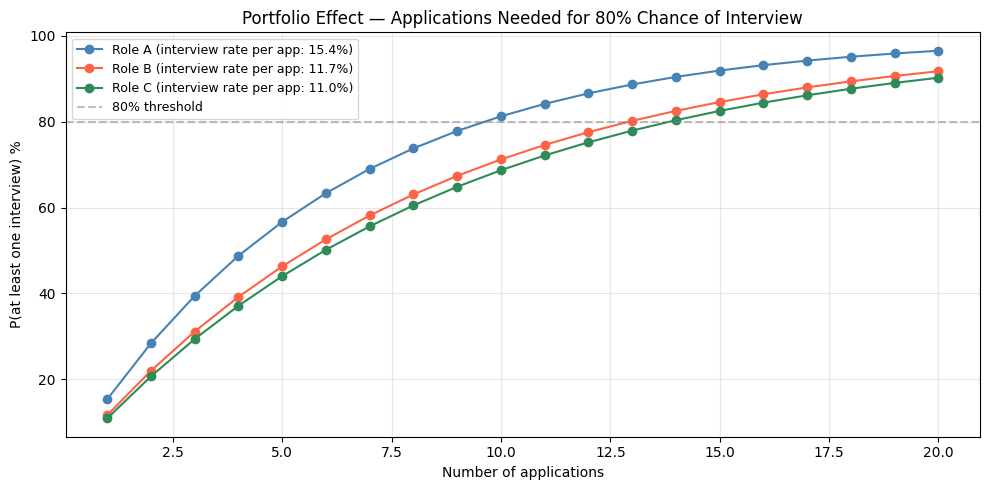

Applications needed for 80% chance of at least one interview:
  Role A: 10 applications
  Role B: 13 applications
  Role C: 14 applications


In [6]:
n_applications = np.arange(1, 21)

# Expected interview rate per application = P(interview | fit)*P(fit) + P(interview | no fit)*P(no fit)
def expected_interview_rate(prior):
    return p_interview_given_fit * prior + p_interview_given_no_fit * (1 - prior)

fig, ax = plt.subplots(figsize=(10, 5))

for role, prior, color in zip(['A', 'B', 'C'],
                               [priors['A'], priors['B'], priors['C']],
                               ['steelblue', 'tomato', 'seagreen']):
    rate = expected_interview_rate(prior)
    p_at_least_one = 1 - (1 - rate) ** n_applications
    ax.plot(n_applications, p_at_least_one * 100, 'o-', color=color,
            label=f'Role {role} (interview rate per app: {rate:.1%})')

ax.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_xlabel('Number of applications')
ax.set_ylabel('P(at least one interview) %')
ax.set_title('Portfolio Effect — Applications Needed for 80% Chance of Interview')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bayesian_job_search_portfolio.png', dpi=150)
plt.show()

print("Applications needed for 80% chance of at least one interview:")
for role, prior in priors.items():
    rate = expected_interview_rate(prior)
    n_needed = int(np.ceil(np.log(1 - 0.80) / np.log(1 - rate)))
    print(f"  Role {role}: {n_needed} applications")

**Key insights:**

1. Two rejections for Role A reduce the belief of strong fit from 20% to ~13% — a meaningful but not catastrophic update. The signal is diluted because rejection is common even for strong candidates.

2. A single interview invitation after two rejections recovers the belief substantially — positive signals are much more informative than negative ones in competitive markets.

3. The portfolio view shows that consistent effort across multiple applications is the dominant strategy — the probability of at least one interview compounds quickly with volume.

**Broader connection:** This sequential belief updating framework maps directly onto A/B testing, online learning algorithms, and recommendation systems — anywhere beliefs about an unknown parameter must be updated as data arrives incrementally.